In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [54]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from mlxtend.plotting import plot_decision_regions

In [24]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.layers import Dense
from keras.models import Sequential
from keras.layers import Dropout
from keras.optimizers import Adam

In [10]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=1000, noise=0.3, random_state=42)

In [20]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [46]:
X

array([[-0.17186341,  0.59624885],
       [ 1.25328273, -0.26541353],
       [ 0.72322405,  0.2319425 ],
       ...,
       [ 1.77095705, -0.50943619],
       [-1.06177158,  0.006786  ],
       [ 0.76117231,  0.65196041]])

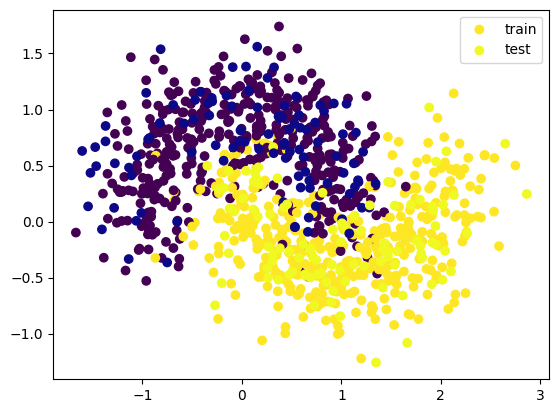

In [22]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', label='train')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='plasma', label='test')
plt.legend()
plt.show()

In [27]:
model_1 = Sequential()
model_1.add(Dense(128 , activation = 'relu' , input_dim = 2))
model_1.add(Dense(128 , activation = 'relu'))
model_1.add(Dense(128 , activation = 'relu'))
model_1.add(Dense(128 , activation = 'relu'))
model_1.add(Dense(1 , activation = 'sigmoid'))
adam = Adam(learning_rate=0.01)
model_1.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])
history = model_1.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test))

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.8462 - loss: 0.3860 - val_accuracy: 0.8300 - val_loss: 0.3327
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8675 - loss: 0.3139 - val_accuracy: 0.8700 - val_loss: 0.2678
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8963 - loss: 0.2603 - val_accuracy: 0.9150 - val_loss: 0.1866
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9038 - loss: 0.2572 - val_accuracy: 0.8450 - val_loss: 0.3462
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9000 - loss: 0.2953 - val_accuracy: 0.9150 - val_loss: 0.2111
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8988 - loss: 0.2593 - val_accuracy: 0.9150 - val_loss: 0.2240
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9087 - loss: 0.2412 - val_accuracy: 0.9050 - val_loss: 0.2079
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9000 - loss: 0.2359 - val_accuracy: 0.9000 - val_loss: 0.

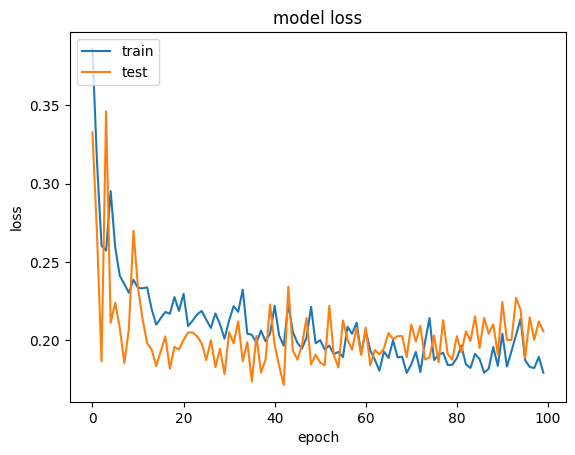

In [28]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [29]:
y_pred_1 = model_1.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step


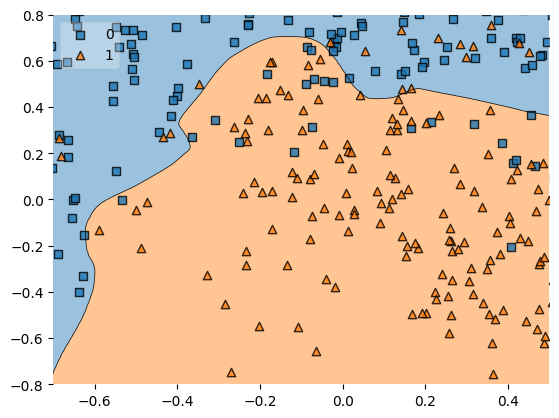

In [56]:
plot_decision_regions(X, y.astype('int'), clf=model_1, legend=2)
plt.xlim(-0.7,0.5)
plt.ylim(-0.8,0.8)
plt.show()

Dropout

we should start with adding dropout layer at the end of final hidden layer only then we should add more if neccesary

In [63]:
model_2 = Sequential()
model_2.add(Dense(128, input_dim=2, activation="relu"))
model_2.add(Dropout(0.2))
model_2.add(Dense(128, activation="relu"))
model_2.add(Dropout(0.2))
model_2.add(Dense(128, activation="relu"))
model_2.add(Dropout(0.2))
model_2.add(Dense(128, activation="relu"))
model_2.add(Dropout(0.2))
model_2.add(Dense(1, activation="linear"))
adam = Adam(learning_rate=0.01)
model_2.compile(loss='mse', optimizer=adam, metrics=['accuracy'])

drop_out_history = model_2.fit(X_train, y_train, epochs=100,
                               validation_data = (X_test, y_test),
                               )

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.7788 - loss: 0.1602 - val_accuracy: 0.8800 - val_loss: 0.0907
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8900 - loss: 0.0960 - val_accuracy: 0.9050 - val_loss: 0.0850
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8750 - loss: 0.1009 - val_accuracy: 0.8950 - val_loss: 0.0726
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8850 - loss: 0.1013 - val_accuracy: 0.8750 - val_loss: 0.0894
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8913 - loss: 0.1037 - val_accuracy: 0.8900 - val_loss: 0.0867
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8863 - loss: 0.0972 - val_accuracy: 0.8950 - val_loss: 0.0809
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8938 - loss: 0.0863 - val_accuracy: 0.9300 - val_loss: 0.0609
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9100 - loss: 0.0748 - val_accuracy: 0.9250 - 

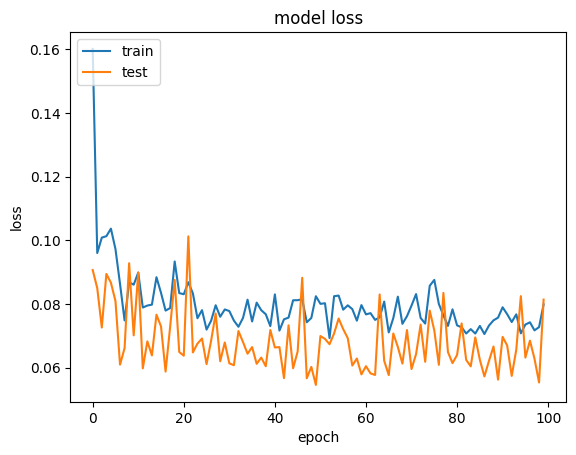

In [64]:
plt.plot(drop_out_history.history['loss'])
plt.plot(drop_out_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step


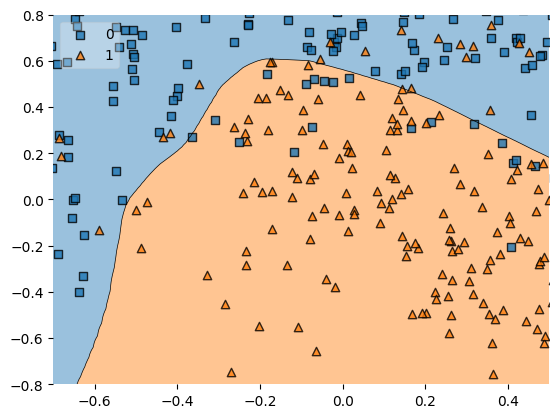

In [65]:
plot_decision_regions(X, y.astype('int'), clf=model_2, legend=2)
plt.xlim(-0.7,0.5)
plt.ylim(-0.8,0.8)
plt.show()